<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


First 5 rows


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


Data types


Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

Missing values


Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

Duplicate rows: 0
Correlation matrix


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


Descriptive statistics


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


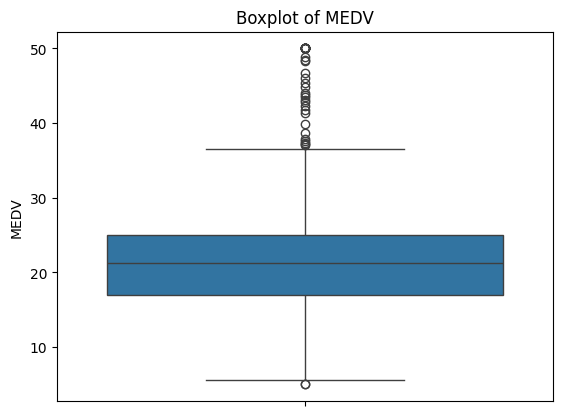

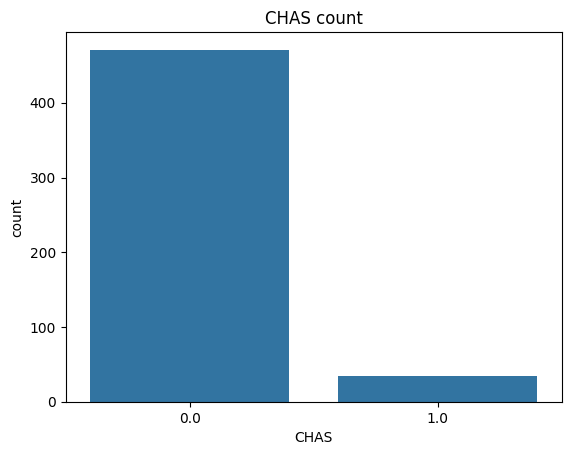

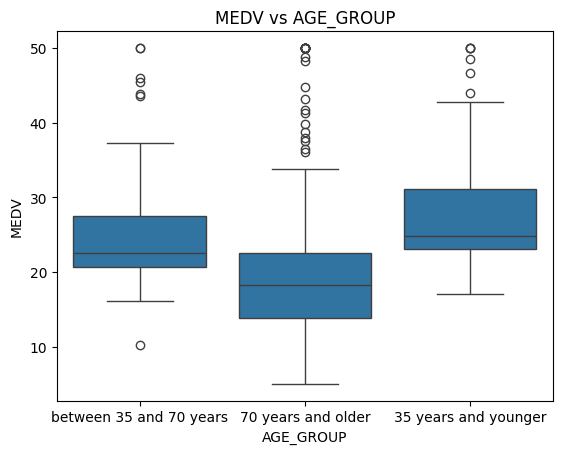

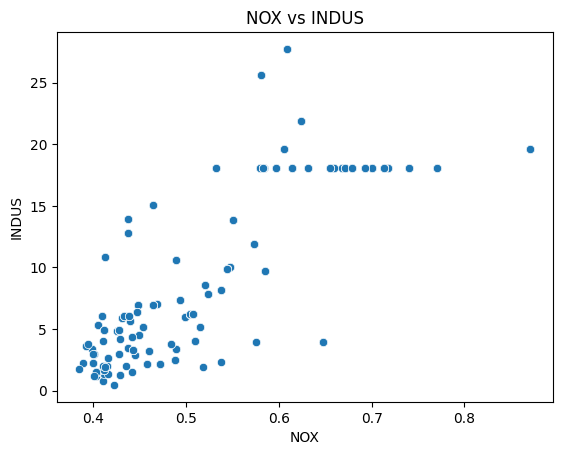

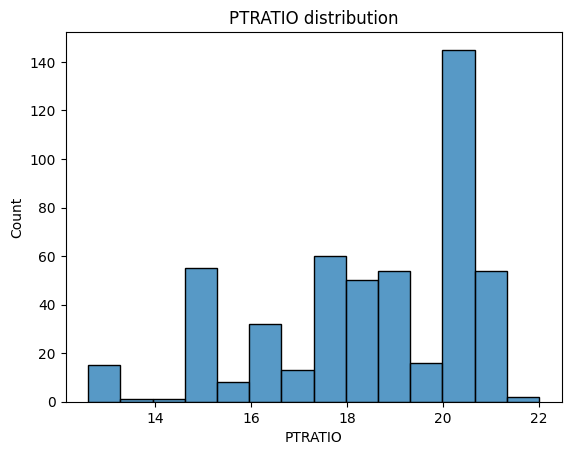

Levene test: LeveneResult(statistic=np.float64(4.590342218715871), pvalue=np.float64(0.03263097600632608))
T-test: TtestResult(statistic=np.float64(-3.996437466090509), pvalue=np.float64(7.390623170519912e-05), df=np.float64(504.0))
ANOVA: F_onewayResult(statistic=np.float64(36.40764999196598), pvalue=np.float64(1.7105011022701524e-15))
Pearson correlation: PearsonRResult(statistic=np.float64(0.7636514469209154), pvalue=np.float64(7.913361061239734e-98))
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.21e-08
Time:                        16:29:30   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                       

In [3]:

# Display first 5 rows
print("First 5 rows")
display(boston_df.head())

# Data types
print("Data types")
display(boston_df.dtypes)

# Missing values
print("Missing values")
display(boston_df.isnull().sum())

# Duplicate rows
print("Duplicate rows:", boston_df.duplicated().sum())

# Correlation matrix
print("Correlation matrix")
display(boston_df.corr())

# Descriptive statistics
print("Descriptive statistics")
display(boston_df.describe())

# Boxplot MEDV
pyplot.figure()
sns.boxplot(y=boston_df['MEDV'])
pyplot.title("Boxplot of MEDV")
pyplot.show()

# Bar plot CHAS
pyplot.figure()
sns.countplot(x='CHAS', data=boston_df)
pyplot.title("CHAS count")
pyplot.show()

# Discretize AGE
boston_df.loc[(boston_df['AGE'] <= 35), 'AGE_GROUP'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35) & (boston_df['AGE'] < 70), 'AGE_GROUP'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'AGE_GROUP'] = '70 years and older'

# Boxplot MEDV vs AGE_GROUP
pyplot.figure()
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df)
pyplot.title("MEDV vs AGE_GROUP")
pyplot.show()

# Scatter NOX vs INDUS
pyplot.figure()
sns.scatterplot(x='NOX', y='INDUS', data=boston_df)
pyplot.title("NOX vs INDUS")
pyplot.show()

# Histogram PTRATIO
pyplot.figure()
sns.histplot(boston_df['PTRATIO'])
pyplot.title("PTRATIO distribution")
pyplot.show()

# Levene test
group0 = boston_df[boston_df['CHAS'] == 0]['MEDV']
group1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
levene = scipy.stats.levene(group0, group1)
print("Levene test:", levene)

# T-test
ttest = scipy.stats.ttest_ind(group0, group1)
print("T-test:", ttest)

# ANOVA AGE groups
g1 = boston_df[boston_df['AGE_GROUP'] == '35 years and younger']['MEDV']
g2 = boston_df[boston_df['AGE_GROUP'] == 'between 35 and 70 years']['MEDV']
g3 = boston_df[boston_df['AGE_GROUP'] == '70 years and older']['MEDV']

anova = scipy.stats.f_oneway(g1, g2, g3)
print("ANOVA:", anova)

# Pearson correlation NOX vs INDUS
pearson = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print("Pearson correlation:", pearson)

# Linear regression DIS vs MEDV
X = sm.add_constant(boston_df['DIS'])
y = boston_df['MEDV']
model = sm.OLS(y, X).fit()

print(model.summary())
